<a href="https://colab.research.google.com/github/jessicaromero-ctrl/Advanced-Math-for-ML/blob/main/Sesion7_Actividad2_GuidanceScale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 7 · Actividad 2
# El control oculto de la IA: Guidance Scale

**Curso:** Introducción a la Inteligencia Artificial Generativa  
**Modalidad:** laboratorio guiado en Google Colab

---

## Propósito

En esta actividad experimentarás con el parámetro **Guidance Scale**, también conocido como **CFG Scale**, para descubrir cómo influye en la relación entre:

- obediencia al prompt;
- libertad creativa;
- naturalidad de la imagen;
- aparición de artefactos.

> **Regla experimental:** cambiaremos únicamente el Guidance Scale.  
> La semilla, el prompt, el número de pasos, el modelo y el tamaño de imagen permanecerán constantes.


### Preguntas iniciales

- ¿Qué ocurrirá si obligamos al modelo a seguir cada vez más el prompt?
- ¿Más obediencia significa siempre una mejor imagen?
- ¿Puede existir un punto en el que “hacer más caso” empeore el resultado?



# 0. Preparación del entorno

En Google Colab selecciona:

**Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU**

Después ejecuta las celdas en orden.

La primera ejecución puede tardar más porque el modelo debe descargarse.


In [2]:
# Verificación del entorno
import torch

print("Versión de PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "No se detectó una GPU. En Google Colab selecciona: "
        "Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU."
    )


Versión de PyTorch: 2.11.0+cu128
GPU disponible: True
GPU detectada: Tesla T4


# 1. Configuración del guardado

Puedes guardar los resultados:

- temporalmente en Colab;
- permanentemente en Google Drive.

Para guardar en Drive cambia `USAR_DRIVE` a `True`.


In [3]:
from pathlib import Path

USAR_DRIVE = True  # Cambia a True si deseas guardar en Google Drive

if USAR_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    CARPETA_RESULTADOS = Path(
        "/content/drive/MyDrive/IA_Generativa/Sesion7/Actividad2_GuidanceScale"
    )
else:
    CARPETA_RESULTADOS = Path("/content/Actividad2_GuidanceScale")

CARPETA_RESULTADOS.mkdir(parents=True, exist_ok=True)
print("Los resultados se guardarán en:", CARPETA_RESULTADOS)


Mounted at /content/drive
Los resultados se guardarán en: /content/drive/MyDrive/IA_Generativa/Sesion7/Actividad2_GuidanceScale


# 2. Instalación de bibliotecas

Usaremos **Diffusers**, una biblioteca especializada en modelos de difusión.


In [4]:
!pip -q install -U diffusers transformers accelerate safetensors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 57.5 MB/s eta 0:00:00


# 3. Carga del modelo

Usaremos Stable Diffusion 1.5 porque puede ejecutarse en una GPU T4 gratuita de Colab y permite controlar directamente los parámetros del proceso de generación.



In [5]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import time

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    use_safetensors=True,
    safety_checker=None
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

# Ajustes para reducir el consumo de memoria en Colab
pipe.enable_model_cpu_offload()
pipe.enable_attention_slicing()

print("Modelo cargado correctamente.")


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Modelo cargado correctamente.


# 4. Diseño del experimento

Mantendremos constantes:

- **Prompt:** una ciudad futurista al atardecer;
- **Semilla:** 42;
- **Pasos:** 25;
- **Tamaño:** 512 × 512 píxeles;
- **Scheduler:** DPM-Solver.

Solo cambiará el **Guidance Scale**.

Los valores serán:

`2, 5, 7.5, 12 y 20`


In [6]:
#PROMPT = "A futuristic city at sunset, cinematic lighting, ultra detailed"
PROMPT = "A futuristic city at sunset, cinematic lighting, ultra detailed"

SEED = 100
STEPS = 25
WIDTH = 512
HEIGHT = 512

#GUIDANCE_VALUES = [2, 5, 7.5, 12, 20]
GUIDANCE_VALUES = [2, 5, 7.5, 12, 20]

def generar_imagen(guidance_scale):
    generator = torch.Generator(device="cuda").manual_seed(SEED)

    inicio = time.time()

    imagen = pipe(
        prompt=PROMPT,
        num_inference_steps=STEPS,
        guidance_scale=guidance_scale,
        width=WIDTH,
        height=HEIGHT,
        generator=generator
    ).images[0]

    duracion = time.time() - inicio

    nombre = str(guidance_scale).replace(".", "_")
    ruta = CARPETA_RESULTADOS / f"guidance_{nombre}.png"
    imagen.save(ruta)

    return imagen, duracion


# 5. Predicción

Antes de ejecutar las generaciones responde:

1. ¿Qué valor producirá la imagen más creativa?
2. ¿Qué valor producirá la imagen más fiel al prompt?
3. ¿Qué valor crees que ofrecerá el mejor equilibrio?
4. ¿Qué podría ocurrir con un valor extremadamente alto?


# 6. Generación de imágenes

El cuaderno generará cinco imágenes con el mismo prompt y la misma semilla.

> **Observa especialmente:**
> - composición;
> - iluminación;
> - cantidad de detalle;
> - naturalidad;
> - presencia de artefactos.


In [7]:
imagenes = []
tiempos = []

for cfg in GUIDANCE_VALUES:
    print(f"Generando imagen con Guidance Scale = {cfg}...")
    imagen, duracion = generar_imagen(cfg)
    imagenes.append(imagen)
    tiempos.append(duracion)

print("Generación terminada.")


Generando imagen con Guidance Scale = 2...


  0%|          | 0/25 [00:00<?, ?it/s]

Generando imagen con Guidance Scale = 5...


  0%|          | 0/25 [00:00<?, ?it/s]

Generando imagen con Guidance Scale = 7.5...


...

Generando imagen con Guidance Scale = 12...


  0%|          | 0/25 [00:00<?, ?it/s]

Generando imagen con Guidance Scale = 20...


  0%|          | 0/25 [00:00<?, ?it/s]

Generación terminada.


# 7. Comparación visual

Las imágenes se mostrarán juntas para facilitar la comparación.


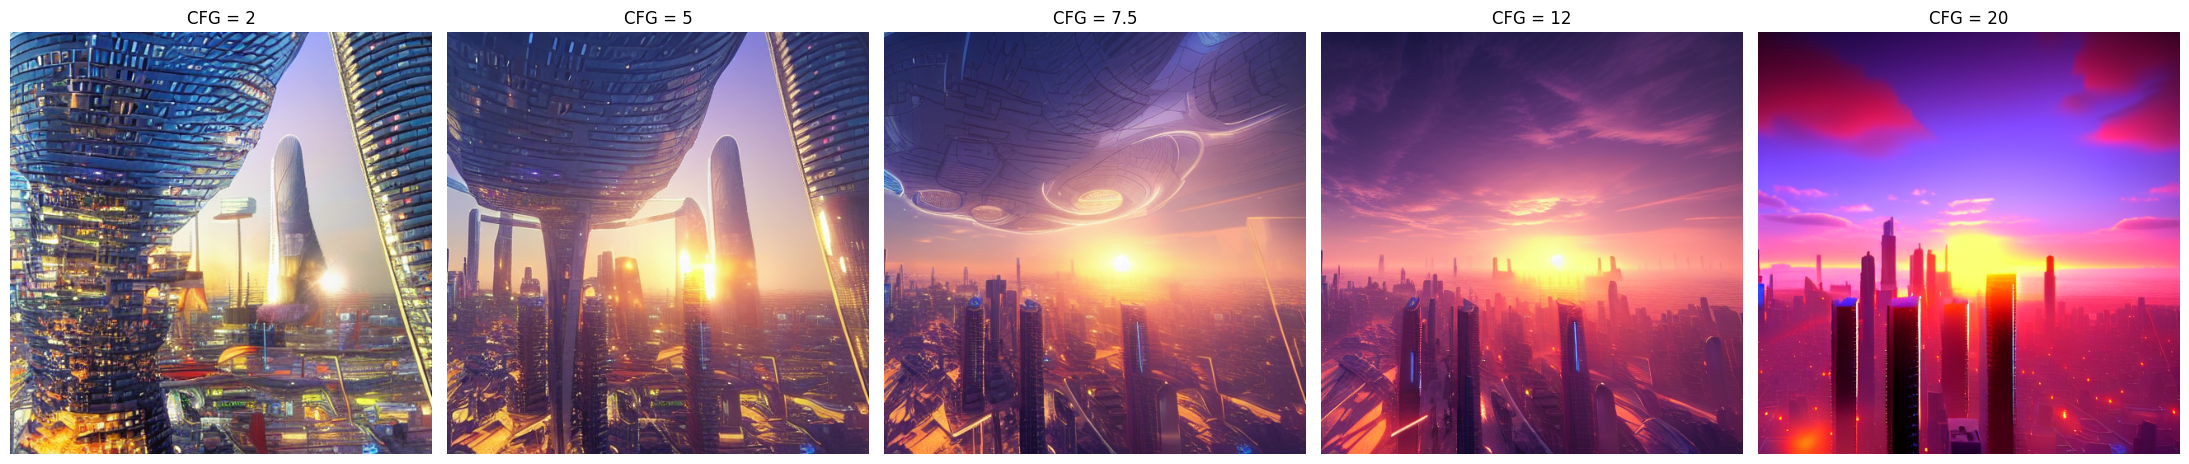

Comparación guardada en: /content/drive/MyDrive/IA_Generativa/Sesion7/Actividad2_GuidanceScale/comparacion_guidance_scale.png


In [8]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, imagen, cfg in zip(axes, imagenes, GUIDANCE_VALUES):
    ax.imshow(imagen)
    ax.set_title(f"CFG = {cfg}")
    ax.axis("off")

plt.tight_layout()

ruta_comparacion = CARPETA_RESULTADOS / "comparacion_guidance_scale.png"
plt.savefig(ruta_comparacion, dpi=150, bbox_inches="tight")
plt.show()

print("Comparación guardada en:", ruta_comparacion)


# 8. Registro de observaciones

Evalúa cada imagen usando una escala de 1 a 5.

| Guidance Scale | Fidelidad al prompt | Creatividad | Naturalidad | Artefactos | Observaciones |
|---:|---:|---:|---:|---:|---|
| 2 | 2| 3| 1| 3| Luce desordenada y desestructurada|
| 5 | 4.5| 4.5| 4.5| 4| Definida a nivel estructural y de elementos|
| 7.5 | 3.5| 3.5| 2| 2| Mezcla de elementos y difusión de formas|
| 12 | 5| 5| 5| 5| Buena definición y fidelidad al prompt|
| 20 | 2| 2| 2| 2| Baja fidelidad y exceso de saturación de color|


In [9]:
# Tabla automática con los tiempos de generación
tabla_tiempos = pd.DataFrame({
    "Guidance Scale": GUIDANCE_VALUES,
    "Tiempo de generación (s)": [round(t, 2) for t in tiempos]
})

tabla_tiempos


,Guidance Scale,Tiempo de generación (s)
0,2.0,11.61
1,5.0,8.75
2,7.5,7.50
3,12.0,8.59
4,20.0,6.56


# 9. Preguntas de análisis

Responde con base en las imágenes obtenidas.

### 1.
¿Cuál imagen siguió mejor el prompt?

### 2.
¿Cuál presentó mayor libertad creativa?

### 3.
¿En qué valor observaste el mejor equilibrio entre fidelidad y naturalidad?

### 4.
¿Aumentar el Guidance Scale mejoró siempre la imagen?

### 5.
¿Aparecieron artefactos o una apariencia artificial en los valores altos?

### 6.
¿El Guidance Scale modificó significativamente el tiempo de generación?

### 7.
Formula una conclusión de dos o tres oraciones:

> El Guidance Scale controla...


> **Reflexión:**  
> “El Guidance Scale no es un control de calidad. Es un control de obediencia. Aumentarlo puede mejorar la alineación con el prompt, pero también puede reducir la naturalidad.”


# 10. Mini reto: descubre el valor oculto

Genera dos imágenes adicionales:

- una con Guidance Scale = 4;
- otra con Guidance Scale = 10.

Después muéstralas a otra persona sin revelar los valores.

La otra persona debe:

1. identificar cuál corresponde a cada valor;
2. justificar su decisión;
3. reconocer que la identificación puede no ser completamente segura.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

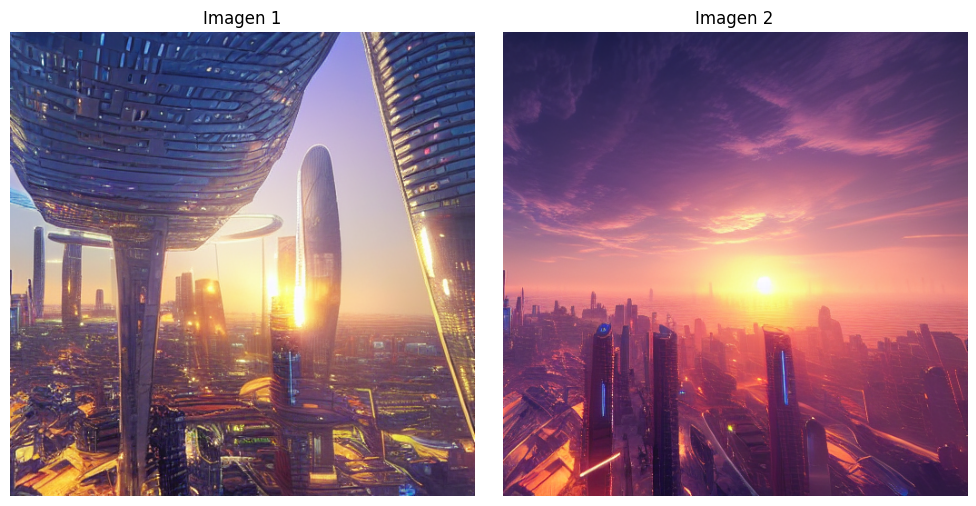

Reto guardado en: /content/drive/MyDrive/IA_Generativa/Sesion7/Actividad2_GuidanceScale/reto_valores_ocultos.png


In [12]:
VALORES_RETO = [4, 10]
imagenes_reto = []

for cfg in VALORES_RETO:
    imagen, _ = generar_imagen(cfg)
    imagenes_reto.append(imagen)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for indice, (ax, imagen) in enumerate(zip(axes, imagenes_reto), start=1):
    ax.imshow(imagen)
    ax.set_title(f"Imagen {indice}")
    ax.axis("off")

plt.tight_layout()

ruta_reto = CARPETA_RESULTADOS / "reto_valores_ocultos.png"
plt.savefig(ruta_reto, dpi=150, bbox_inches="tight")
plt.show()

print("Reto guardado en:", ruta_reto)


## Reflexión del mini reto

- ¿Qué imagen asignaste al valor 4?
- ¿Qué imagen asignaste al valor 10?
- ¿Qué evidencia utilizaste?
- ¿La diferencia fue evidente o ambigua?
- ¿Qué demuestra esto sobre la relación entre parámetros y resultados?


# 11. Evidencia de aprendizaje

Entrega:

1. la comparación de los cinco valores;
2. la tabla de observaciones;
3. las respuestas de análisis;
4. la imagen del reto;
5. una conclusión personal de máximo 100 palabras.




# 12. Cierre conceptual

El Guidance Scale representa cuánto debe favorecer el modelo la información del prompt durante la generación.

De forma simplificada:

- **valor bajo:** mayor libertad;
- **valor intermedio:** equilibrio;
- **valor alto:** mayor obediencia, con riesgo de artificialidad.

La idea más importante es:

> **Un parámetro más alto no garantiza una imagen mejor.**
